In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import sqlite3

def init_database():
    conn = sqlite3.connect("ap_exceptions.db")
    c = conn.cursor()

    for table in ["invoices", "purchase_orders", "receipts", "po_amendments", "policy"]:
        c.execute(f"DROP TABLE IF EXISTS {table}")

    c.execute('''CREATE TABLE invoices
                 (invoice_id TEXT PRIMARY KEY,
                  vendor TEXT,
                  po_id TEXT,
                  item TEXT,
                  quantity INTEGER,
                  unit_price REAL,
                  status TEXT,
                  note TEXT)''')

    c.execute('''CREATE TABLE purchase_orders
                 (po_id TEXT PRIMARY KEY,
                  vendor TEXT,
                  item TEXT,
                  quantity INTEGER,
                  unit_price REAL)''')

    c.execute('''CREATE TABLE receipts
                 (po_id TEXT PRIMARY KEY,
                  quantity_received INTEGER)''')

    c.execute('''CREATE TABLE po_amendments
                 (po_id TEXT,
                  new_unit_price REAL,
                  effective_date TEXT,
                  reason TEXT)''')

    c.execute('''CREATE TABLE policy
                 (rule_name TEXT PRIMARY KEY,
                  max_percent REAL,
                  description TEXT)''')

    c.executemany("INSERT INTO invoices VALUES (?,?,?,?,?,?,?,?)", [
        ("INV-1044", "Acme",       "PO-17", "Widget",  10, 112.00, "On hold", ""),
        ("INV-1045", "Brightline", "PO-18", "Bracket",  5,  60.00, "On hold", ""),
        ("INV-1046", "Corex",      "PO-19", "Gear",    20,   8.20, "On hold", ""),
    ])

    c.executemany("INSERT INTO purchase_orders VALUES (?,?,?,?,?)", [
        ("PO-17", "Acme",       "Widget",  10, 100.00),
        ("PO-18", "Brightline", "Bracket",  5,  50.00),
        ("PO-19", "Corex",      "Gear",    20,   8.00),
    ])

    c.executemany("INSERT INTO receipts VALUES (?,?)", [
        ("PO-17", 10),
        ("PO-18", 5),
        ("PO-19", 20),
    ])

    # Only PO-17 has an official price change
    c.execute("INSERT INTO po_amendments VALUES (?,?,?,?)",
              ("PO-17", 110.00, "2026-09-01", "Steel cost increase agreed with the buyer"))

    c.execute("INSERT INTO policy VALUES (?,?,?)", (
        "price_tolerance",
        5.0,
        "Invoice unit price may be at most 5 percent above the PO unit price. "
        "Within tolerance: approve payment. Above tolerance: request a credit for the extra amount.",
    ))

    conn.commit()
    conn.close()
    print("Database ready: ap_exceptions.db")

init_database()

Database ready: ap_exceptions.db


In [3]:
import sqlite3
from typing import Literal
from langchain_core.tools import tool

DB_PATH = "ap_exceptions.db"

def run_query(sql, params=()):
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    rows = [dict(row) for row in conn.execute(sql, params).fetchall()]
    conn.close()
    return rows

# ---------- Matcher tools ----------
@tool
def get_invoice(invoice_id: str) -> dict:
    """Get one supplier invoice by id, for example INV-1044."""
    rows = run_query("SELECT * FROM invoices WHERE invoice_id = ?", (invoice_id,))
    return rows[0] if rows else {"error": f"No invoice {invoice_id}"}

@tool
def get_purchase_order(po_id: str) -> dict:
    """Get the original purchase order (agreed item, quantity, unit price) by id, for example PO-17."""
    rows = run_query("SELECT * FROM purchase_orders WHERE po_id = ?", (po_id,))
    return rows[0] if rows else {"error": f"No purchase order {po_id}"}

@tool
def get_receipt(po_id: str) -> dict:
    """Get how many units the warehouse actually received for a purchase order."""
    rows = run_query("SELECT * FROM receipts WHERE po_id = ?", (po_id,))
    return rows[0] if rows else {"error": f"No receipt for {po_id}"}

@tool
def compare_prices(invoice_unit_price: float, po_unit_price: float, quantity: int) -> dict:
    """Calculate how far the invoice unit price is above the PO unit price."""
    unit_difference = invoice_unit_price - po_unit_price
    return {
        "unit_difference": round(unit_difference, 2),
        "total_difference": round(unit_difference * quantity, 2),
        "percent_over": round(unit_difference / po_unit_price * 100, 2),
    }

# ---------- PolicyChecker tool ----------
@tool
def get_price_tolerance() -> dict:
    """Get the company's price tolerance rule (max_percent)."""
    return run_query("SELECT * FROM policy WHERE rule_name = 'price_tolerance'")[0]

# ---------- ContractChecker tool ----------
@tool
def get_po_amendments(po_id: str) -> dict:
    """List official price amendments for a purchase order. An empty list means the price was never changed."""
    rows = run_query(
        "SELECT * FROM po_amendments WHERE po_id = ? ORDER BY effective_date", (po_id,)
    )
    return {"po_id": po_id, "amendments": rows}

# ---------- CaseUpdater tool ----------
@tool
def update_case(
    invoice_id: str,
    status: Literal["Approved to pay", "Credit requested"],
    note: str,
) -> dict:
    """Record the final decision on an invoice and return the updated row."""
    conn = sqlite3.connect(DB_PATH)
    conn.execute(
        "UPDATE invoices SET status = ?, note = ? WHERE invoice_id = ?",
        (status, note, invoice_id),
    )
    conn.commit()
    conn.close()
    rows = run_query(
        "SELECT invoice_id, status, note FROM invoices WHERE invoice_id = ?", (invoice_id,)
    )
    return rows[0] if rows else {"error": f"No invoice {invoice_id}"}

matcher_tools = [get_invoice, get_purchase_order, get_receipt, compare_prices]
policy_tools = [get_price_tolerance]
contract_tools = [get_po_amendments]
case_tools = [update_case]

print("Tools ready.")

Tools ready.


In [4]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

COMMON_RULES = """
Never ask for confirmation. Work autonomously.
Keep your answer short: a few lines of findings, then the CONCLUSION line.
"""

matcher_agent = create_agent(
    model=llm,
    tools=matcher_tools,
    system_prompt="""You are the Matcher on an accounts-payable review desk.
You compare a supplier invoice with its purchase order (PO) and goods receipt.

Steps:
1. get_invoice for the invoice in the request. Note its po_id.
2. get_purchase_order and get_receipt for that po_id.
3. Check that invoice quantity, PO quantity, and received quantity agree.
4. Call compare_prices with the invoice unit price, the PO unit price, and the invoice quantity.

RE-MATCH RULE: If the conversation contains a ContractChecker message with AMENDMENT FOUND for this PO,
use the amended unit price as the PO unit price in compare_prices, and use RE-MATCH in your conclusion.

End with exactly one line in one of these forms:
CONCLUSION: MATCH INV-1044 (PO PO-17). Quantity matches. Invoice 112 vs PO 100: 12.0 percent over, 120.0 total.
CONCLUSION: RE-MATCH INV-1044 (PO PO-17) using amended price 110. Quantity matches. Invoice 112 vs PO 110: 1.82 percent over, 20.0 total.
""" + COMMON_RULES,
)

policy_agent = create_agent(
    model=llm,
    tools=policy_tools,
    system_prompt="""You are the PolicyChecker on an accounts-payable review desk.
You decide whether a price gap is acceptable under company policy.

Use the MOST RECENT Matcher conclusion in the conversation (MATCH or RE-MATCH).
Call get_price_tolerance to read max_percent. Compare percent_over with max_percent.
You cannot see invoices, POs, or amendments. Never invent numbers.

End with exactly one line in one of these forms:
CONCLUSION: WITHIN TOLERANCE. 1.82 percent is within the 5 percent limit. Approve payment.
CONCLUSION: EXCEEDS TOLERANCE. 12.0 percent is above the 5 percent limit. Extra charge is 120.0.

If the user only asks about the policy itself, report it and end with:
CONCLUSION: POLICY. Invoice price may be at most 5 percent above the PO.
""" + COMMON_RULES,
)

contract_agent = create_agent(
    model=llm,
    tools=contract_tools,
    system_prompt="""You are the ContractChecker on an accounts-payable review desk.
You check whether a purchase order's price was officially amended.

Find the PO id in the Matcher's conclusion or in the user's request.
Call get_po_amendments for it. If there are several amendments, the latest effective_date wins.

End with exactly one line in one of these forms:
CONCLUSION: AMENDMENT FOUND. PO-17 unit price changed to 110 on 2026-09-01 (reason).
CONCLUSION: NO AMENDMENT. PO-18 price is unchanged.
""" + COMMON_RULES,
)

case_agent = create_agent(
    model=llm,
    tools=case_tools,
    system_prompt="""You are the CaseUpdater on an accounts-payable review desk.
You record the final decision on the invoice from the user's request.

Read the MOST RECENT PolicyChecker conclusion:
- WITHIN TOLERANCE  -> status "Approved to pay"
- EXCEEDS TOLERANCE -> status "Credit requested"
Write a one-sentence note with the percent over, the 5 percent limit, and the credit amount if any.
If an amended PO price was used, mention the amendment in the note.
Call update_case once. Do not recalculate anything.

End with exactly one line. The status in that line must be the same status you passed to update_case:
CONCLUSION: CASE UPDATED. INV-1044 is now Approved to pay.
CONCLUSION: CASE UPDATED. INV-1045 is now Credit requested.
""" + COMMON_RULES,
)

print("Workers ready.")

Workers ready.


In [5]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel, Field

supervisor_prompt = """
You are the supervisor of an accounts-payable review desk. You do not do the work yourself.
After each worker reports, read the whole conversation and decide who should act next.

Your workers:
- Matcher: compares invoice vs PO vs receipt. Can re-match using an amended PO price.
- PolicyChecker: decides whether a price gap is within the allowed tolerance.
- ContractChecker: checks whether the PO price was officially amended.
- CaseUpdater: records the final decision on the invoice.

STEP 1: Look at the user's FIRST message and classify it:
- RESOLVE: the user asks to resolve, review, or process an invoice.
- QUESTION: the user asks for one fact (for example "Has PO-17 been amended?" or "What is our price tolerance?").

STEP 2 for RESOLVE requests: follow this playbook. Base every decision on the latest findings:
- No Matcher conclusion yet -> Matcher.
- The most recent worker message is from Matcher -> PolicyChecker (new numbers need a policy verdict).
- PolicyChecker says WITHIN TOLERANCE -> CaseUpdater.
- PolicyChecker says EXCEEDS TOLERANCE:
    - ContractChecker has not run yet -> ContractChecker (maybe the PO price was changed).
    - ContractChecker already ran -> CaseUpdater (nothing else can explain the gap).
- ContractChecker says AMENDMENT FOUND -> Matcher (re-match against the amended price).
- ContractChecker says NO AMENDMENT -> CaseUpdater.
- CaseUpdater says CASE UPDATED -> FINISH.

STEP 2 for QUESTION requests: the playbook above does NOT apply.
- No worker has answered yet -> the one worker who owns that fact
  (amendments -> ContractChecker, tolerance or policy -> PolicyChecker, invoice or PO details -> Matcher).
- That worker has posted its CONCLUSION -> FINISH. Do not re-match, apply policy, or update any case.
- You cannot answer questions yourself, so never FINISH before a worker has answered.

Safety limits: ContractChecker at most once per request. CaseUpdater at most once per request.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", supervisor_prompt),
    MessagesPlaceholder(variable_name="messages"),
    ("system", "Based on the findings so far, who should act next? Or should we FINISH?"),
])

class Route(BaseModel):
    request_type: Literal["RESOLVE", "QUESTION"] = Field(description="Classification of the user's first message.")
    reason: str = Field(description="One short sentence: what the latest finding is and why this is the next step.")
    next: Literal["Matcher", "PolicyChecker", "ContractChecker", "CaseUpdater", "FINISH"]

supervisor_chain = prompt | llm.with_structured_output(Route)

def supervisor_node(state):
    route = supervisor_chain.invoke({"messages": state["messages"]})
    print(f"\n>>> SUPERVISOR [{route.request_type}] -> {route.next}   (reason: {route.reason})")
    return {"next": route.next}

In [7]:
import operator
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]
    next: str

def agent_node(agent, name):
    """Wrap a worker so it runs on the shared conversation and labels its reply."""
    def node(state):
        result = agent.invoke({"messages": state["messages"]})
        content = result["messages"][-1].content
        print(f"\n[{name}]\n{content}")
        return {"messages": [HumanMessage(content=f"{name}: {content}", name=name)]}
    return node

workflow = StateGraph(AgentState)

#here instead of node if we add agent directly then in the messages we will see the tool calls, with nodes
#we won't see any tool calls , as the messages will be the node response of human message format
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("Matcher", agent_node(matcher_agent, "Matcher"))
workflow.add_node("PolicyChecker", agent_node(policy_agent, "PolicyChecker"))
workflow.add_node("ContractChecker", agent_node(contract_agent, "ContractChecker"))
workflow.add_node("CaseUpdater", agent_node(case_agent, "CaseUpdater"))

workflow.set_entry_point("supervisor")
workflow.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "Matcher": "Matcher",
        "PolicyChecker": "PolicyChecker",
        "ContractChecker": "ContractChecker",
        "CaseUpdater": "CaseUpdater",
        "FINISH": END,
    },
)
for worker in ["Matcher", "PolicyChecker", "ContractChecker", "CaseUpdater"]:
    workflow.add_edge(worker, "supervisor")

graph = workflow.compile()

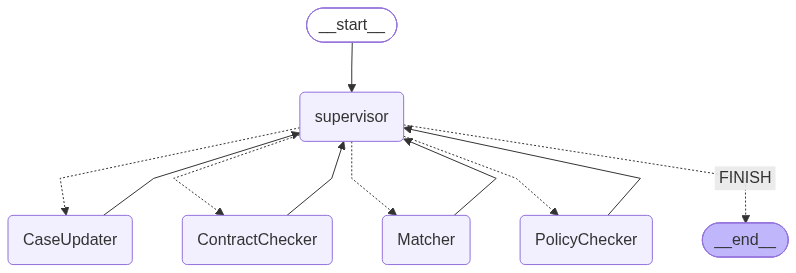

In [8]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [9]:
def resolve(invoice_id):
    query = f"Resolve on-hold invoice {invoice_id}."
    print("=" * 70)
    print("REQUEST:", query)
    print("=" * 70)

    result = graph.invoke(
        {"messages": [HumanMessage(content=query)]},
        config={"recursion_limit": 25},
    )

    path = [m.name for m in result["messages"] if m.name]
    print("\nPATH TAKEN:", " -> ".join(path + ["FINISH"]))
    print(f"Worker calls: {len(path)}")
    return path

In [10]:
path_1046 = resolve("INV-1046")

REQUEST: Resolve on-hold invoice INV-1046.

>>> SUPERVISOR [RESOLVE] -> Matcher   (reason: No Matcher conclusion yet for invoice INV-1046, so Matcher should act first.)

[Matcher]
Quantity matches for invoice INV-1046, PO PO-19: invoice quantity 20, PO quantity 20, received quantity 20.
Invoice unit price 8.2 vs PO unit price 8.0: 2.5 percent over, 4.0 total.

CONCLUSION: MATCH INV-1046 (PO PO-19). Quantity matches. Invoice 8.2 vs PO 8.0: 2.5 percent over, 4.0 total.

>>> SUPERVISOR [RESOLVE] -> PolicyChecker   (reason: Matcher has completed matching and found a price difference that needs policy evaluation.)

[PolicyChecker]
Invoice unit price is 2.5 percent above the PO unit price. The company policy allows up to 5 percent price tolerance.

CONCLUSION: WITHIN TOLERANCE. 2.5 percent is within the 5 percent limit. Approve payment.

>>> SUPERVISOR [RESOLVE] -> CaseUpdater   (reason: PolicyChecker concluded the price difference is within tolerance, so the case should be updated according

In [11]:
path_1045 = resolve("INV-1045")

REQUEST: Resolve on-hold invoice INV-1045.

>>> SUPERVISOR [RESOLVE] -> Matcher   (reason: No Matcher conclusion yet for invoice INV-1045, so Matcher should act first.)

[Matcher]
Invoice quantity (5), PO quantity (5), and received quantity (5) all match. The invoice unit price is 20.0 percent over the PO unit price, totaling 50.0 over the entire invoice.

CONCLUSION: MATCH INV-1045 (PO PO-18). Quantity matches. Invoice 60 vs PO 50: 20.0 percent over, 50.0 total.

>>> SUPERVISOR [RESOLVE] -> PolicyChecker   (reason: Matcher found a 20% price overage, so the next step is to check if this price gap is within the allowed tolerance.)

[PolicyChecker]
The invoice unit price is 20.0 percent over the PO unit price, which exceeds the company's price tolerance of 5 percent.

CONCLUSION: EXCEEDS TOLERANCE. 20.0 percent is above the 5 percent limit. Extra charge is 50.0.

>>> SUPERVISOR [RESOLVE] -> ContractChecker   (reason: PolicyChecker found the price gap exceeds tolerance, so ContractChecker

In [12]:
path_1044 = resolve("INV-1044")

REQUEST: Resolve on-hold invoice INV-1044.

>>> SUPERVISOR [RESOLVE] -> Matcher   (reason: No Matcher conclusion yet for invoice INV-1044, so Matcher should act next.)

[Matcher]
Invoice INV-1044 matches PO PO-17 in quantity: 10 units invoiced, ordered, and received. The invoice unit price is 12.0% over the PO unit price, totaling 120.0 over the PO amount.

CONCLUSION: MATCH INV-1044 (PO PO-17). Quantity matches. Invoice 112 vs PO 100: 12.0 percent over, 120.0 total.

>>> SUPERVISOR [RESOLVE] -> PolicyChecker   (reason: Matcher found a price gap of 12%, so PolicyChecker must decide if this is within tolerance.)

[PolicyChecker]
The invoice price is 12.0 percent above the PO price. The company policy allows at most 5 percent over the PO price.

CONCLUSION: EXCEEDS TOLERANCE. 12.0 percent is above the 5 percent limit. Extra charge is 120.0.

>>> SUPERVISOR [RESOLVE] -> ContractChecker   (reason: PolicyChecker found the price exceeds tolerance, so ContractChecker should verify if the PO p

In [13]:
import sqlite3
import pandas as pd

def show_tables(*tables):
    conn = sqlite3.connect("ap_exceptions.db")
    for table in tables:
        print(table.upper())
        display(pd.read_sql(f"SELECT * FROM {table}", conn))
    conn.close()

for invoice_id, path in [("INV-1046", path_1046), ("INV-1045", path_1045), ("INV-1044", path_1044)]:
    print(f"{invoice_id}: {' -> '.join(path)} -> FINISH")

show_tables("invoices")

INV-1046: Matcher -> PolicyChecker -> CaseUpdater -> FINISH
INV-1045: Matcher -> PolicyChecker -> ContractChecker -> CaseUpdater -> FINISH
INV-1044: Matcher -> PolicyChecker -> ContractChecker -> Matcher -> PolicyChecker -> CaseUpdater -> FINISH
INVOICES


,invoice_id,vendor,po_id,item,quantity,unit_price,status,note
0,INV-1044,Acme,PO-17,Widget,10,112.0,Approved to pay,Invoice price is 1.82% over the amended PO pri...
1,INV-1045,Brightline,PO-18,Bracket,5,60.0,Credit requested,Invoice unit price is 20.0% over the 5% tolera...
2,INV-1046,Corex,PO-19,Gear,20,8.2,Approved to pay,"Invoice unit price is 2.5% over the PO price, ..."


In [14]:
for question in ["Has PO-17 had a price amendment?", "What is our price tolerance?"]:
    print("=" * 70)
    print("QUESTION:", question)
    result = graph.invoke(
        {"messages": [HumanMessage(content=question)]},
        config={"recursion_limit": 10},
    )
    path = [m.name for m in result["messages"] if m.name]
    print("\nPATH TAKEN:", " -> ".join(path + ["FINISH"]))

QUESTION: Has PO-17 had a price amendment?

>>> SUPERVISOR [QUESTION] -> ContractChecker   (reason: User asks if PO-17 has had a price amendment, which is a fact owned by ContractChecker.)

[ContractChecker]
PO-17 has one price amendment effective on 2026-09-01, changing the unit price to 110 due to a steel cost increase agreed with the buyer.

CONCLUSION: AMENDMENT FOUND. PO-17 unit price changed to 110 on 2026-09-01 (Steel cost increase agreed with the buyer).

>>> SUPERVISOR [QUESTION] -> FINISH   (reason: ContractChecker has answered the question about PO-17's price amendment.)

PATH TAKEN: ContractChecker -> FINISH
QUESTION: What is our price tolerance?

>>> SUPERVISOR [QUESTION] -> PolicyChecker   (reason: The user asks for the price tolerance, which is a policy fact owned by PolicyChecker.)

[PolicyChecker]
Invoice price may be at most 5 percent above the PO.

CONCLUSION: POLICY. Invoice price may be at most 5 percent above the PO.

>>> SUPERVISOR [QUESTION] -> FINISH   (reason: